#### We have cooking actions like:

- Mix
- Stir
- Boil
- Fry
- Bake

While some may appear very frequently, some are rare and require a large corpus of recipes to be included in the set of unique actions — hence they form the **heavy tail** of the rank-frequency distribution.

Our task is to test whether their frequency distribution follows a **power-law (Zipf's Law)** distribution:

$$f(r) \propto r^{-\beta}$$

where $f(r)$ is the frequency of the action with rank $r$. This can also be written as:

$$P(r) \propto r^{-\alpha}$$

where $P(r) = \dfrac{f(r)}{\sum f}$ is the relative frequency across all actions.

In [8]:
# =============================================================================
# IMPROVED ZIPF ANALYSIS
# Distribution Comparison + Bootstrap CI
# =============================================================================

import pandas as pd
import numpy as np
import powerlaw

# =========================================================
# LOAD DATA
# =========================================================

print("Loading data...")

df_actions_raw = pd.read_excel(
    "Datasets/RecipeID_CookingAction_List.xlsx"
)

df_actions_raw = df_actions_raw.dropna(
    subset=['Processes']
)

df_actions_raw['Processes'] = (
    df_actions_raw['Processes']
    .astype(str)
    .str.split(r'\|\|')
)

df_actions = (
    df_actions_raw
    .explode('Processes')
    .reset_index(drop=True)
)

df_actions['Processes'] = (
    df_actions['Processes']
    .str.strip()
)

df_actions = df_actions.rename(
    columns={
        'Recipe_id': 'recipe_no',
        'Processes': 'action_id'
    }
)

# =========================================================
# FREQUENCY DATA
# =========================================================

data = (
    df_actions['action_id']
    .value_counts()
    .values
)

# =========================================================
# FIT POWER LAW
# =========================================================

print("\nFitting power law...")

fit = powerlaw.Fit(
    data,
    discrete=True,
    verbose=False
)

alpha = fit.alpha
sigma = fit.sigma
xmin = fit.xmin

beta = 1.0 / (alpha - 1.0)

# =========================================================
# DISTRIBUTION COMPARISONS
# =========================================================

print("\n--- Distribution Comparisons ---")

comparisons = [
    ('power_law', 'lognormal'),
    ('power_law', 'exponential'),
    ('power_law', 'truncated_power_law')
]

comparison_results = []

for dist1, dist2 in comparisons:

    R, p = fit.distribution_compare(dist1, dist2)

    comparison_results.append({
        'Distribution_1': dist1,
        'Distribution_2': dist2,
        'LogLikelihood_Ratio': R,
        'p_value': p
    })

    print(f"\n{dist1} vs {dist2}")
    print(f"R = {R:.4f}")
    print(f"p = {p:.6f}")

    if p < 0.05:
        if R > 0:
            print(f"→ {dist1} fits significantly better")
        else:
            print(f"→ {dist2} fits significantly better")
    else:
        print("→ No statistically significant difference")

# =========================================================
# BOOTSTRAP CONFIDENCE INTERVAL
# =========================================================

print("\n--- Bootstrap Confidence Interval ---")

n_bootstrap = 200
bootstrap_alphas = []

np.random.seed(42)

for i in range(n_bootstrap):

    # resample with replacement
    sample = np.random.choice(
        data,
        size=len(data),
        replace=True
    )

    try:

        sample_fit = powerlaw.Fit(
            sample,
            discrete=True,
            verbose=False
        )

        bootstrap_alphas.append(
            sample_fit.alpha
        )

    except:
        continue

bootstrap_alphas = np.array(
    bootstrap_alphas
)

ci_lower = np.percentile(
    bootstrap_alphas,
    2.5
)

ci_upper = np.percentile(
    bootstrap_alphas,
    97.5
)

print(f"\nAlpha = {alpha:.6f}")
print(f"Bootstrap 95% CI = [{ci_lower:.6f}, {ci_upper:.6f}]")

# =========================================================
# EXPORT RESULTS
# =========================================================

results_df = pd.DataFrame({
    "xmin": [xmin],
    "alpha": [alpha],
    "sigma": [sigma],
    "beta": [beta],
    "bootstrap_ci_lower": [ci_lower],
    "bootstrap_ci_upper": [ci_upper]
})

results_df.to_csv(
    "improved_zipf_parameters.csv",
    index=False
)

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df.to_csv(
    "distribution_comparison_results.csv",
    index=False
)

print("\nResults exported successfully.")

Loading data...

Fitting power law...

--- Distribution Comparisons ---

power_law vs lognormal
R = -8.0446
p = 0.008439
→ lognormal fits significantly better

power_law vs exponential
R = 176.2787
p = 0.000000
→ power_law fits significantly better


C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



power_law vs truncated_power_law
R = -11.4771
p = 0.000002
→ truncated_power_law fits significantly better

--- Bootstrap Confidence Interval ---

Alpha = 1.451492
Bootstrap 95% CI = [1.385181, 2.145133]

Results exported successfully.


# Improved Statistical Modeling of Cooking-Action Frequencies

The original analysis assumed that the distribution of cooking-action frequencies follows a pure power-law (Zipf-like) distribution. While power-law fitting is commonly used in complex systems analysis, relying solely on visual agreement or a single fitted model can lead to misleading conclusions.

To improve the rigor of the analysis, we extended the methodology in two important ways:

---

## 1. Comparative Distribution Modeling

Instead of assuming that the data follows a power law, we statistically compared multiple candidate distributions:

- Power Law
- Lognormal
- Exponential
- Truncated Power Law

using likelihood-ratio based model comparison provided by the `powerlaw` package.

For each pair of candidate models, we computed:

- **Log-likelihood ratio (R)**  
  - Positive \(R\): first distribution fits better
  - Negative \(R\): second distribution fits better

- **p-value**
  - Small \(p\)-value indicates statistically significant preference.

### Results

| Comparison | Result |
|---|---|
| Power law vs Lognormal | Lognormal fits significantly better |
| Power law vs Exponential | Power law fits significantly better |
| Power law vs Truncated Power Law | Truncated power law fits significantly better |

---

## Interpretation

The results indicate that:

- the data is **not adequately explained by a simple exponential process**, since the power law strongly outperforms the exponential distribution.
- however, a **pure scale-free power law is also insufficient**, because both the lognormal and truncated power law provide significantly better fits.

This suggests that cooking-action organization exhibits:

- heavy-tailed behaviour,
- but with finite-size or constrained-system effects.

In real culinary systems, physical, cognitive, and procedural constraints naturally limit the unlimited scale-invariance predicted by ideal power laws. Therefore, truncated or lognormal structures may provide a more realistic generative description of cooking behaviour.

---

# Why This Improves Upon Conventional Analysis

Traditional Zipf-law analyses often:

- visually inspect log-log plots,
- fit only a power law,
- and directly report the exponent.

In contrast, our approach:

- tests competing hypotheses statistically,
- avoids assuming scale invariance a priori,
- and identifies the most plausible generative distribution.

This makes the conclusions:

- statistically stronger,
- more reproducible,
- and scientifically more defensible.

---

# 2. Bootstrap-Based Confidence Intervals

The original implementation estimated uncertainty using a normal approximation:

\[
\alpha \pm 1.96\sigma
\]

which assumes approximate Gaussian behaviour of the estimator.

To obtain a more robust estimate of uncertainty, we additionally performed bootstrap resampling:

1. repeatedly resampled the empirical data with replacement,
2. refit the model for each bootstrap sample,
3. computed the empirical distribution of the estimated exponent.

This produced a bootstrap-based 95% confidence interval:

\[
\alpha = 1.451
\]
\[
95\% \text{ CI } = [1.385,\ 2.145]
\]

---

# Significance of Bootstrap Estimation

Bootstrap estimation is advantageous because:

- it does not strongly rely on asymptotic assumptions,
- it is more robust for heavy-tailed data,
- and it better captures uncertainty in empirical complex systems.

Thus, the resulting confidence intervals are statistically more reliable than standard analytical approximations.

---

# Overall Conclusion

The extended analysis demonstrates that culinary action-frequency distributions exhibit strong heavy-tailed organization, but are better described by constrained heavy-tailed models such as truncated power laws or lognormal distributions rather than an unconstrained pure power law.

This provides a more nuanced and statistically rigorous understanding of universal statistical patterns governing culinary design.

Loading data...

Analyzing 26 cuisines...



C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Middle Eastern: alpha=1.4492, sigma=0.0328, Best=Truncated Power Law


C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Rest Africa: alpha=1.4303, sigma=0.0299, Best=Truncated Power Law


...

US: alpha=1.4534, sigma=0.0348, Best=Truncated Power Law


C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Canadian: alpha=1.4263, sigma=0.0291, Best=Truncated Power Law


C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Central American: alpha=1.4516, sigma=0.0323, Best=Truncated Power Law

Results exported successfully.


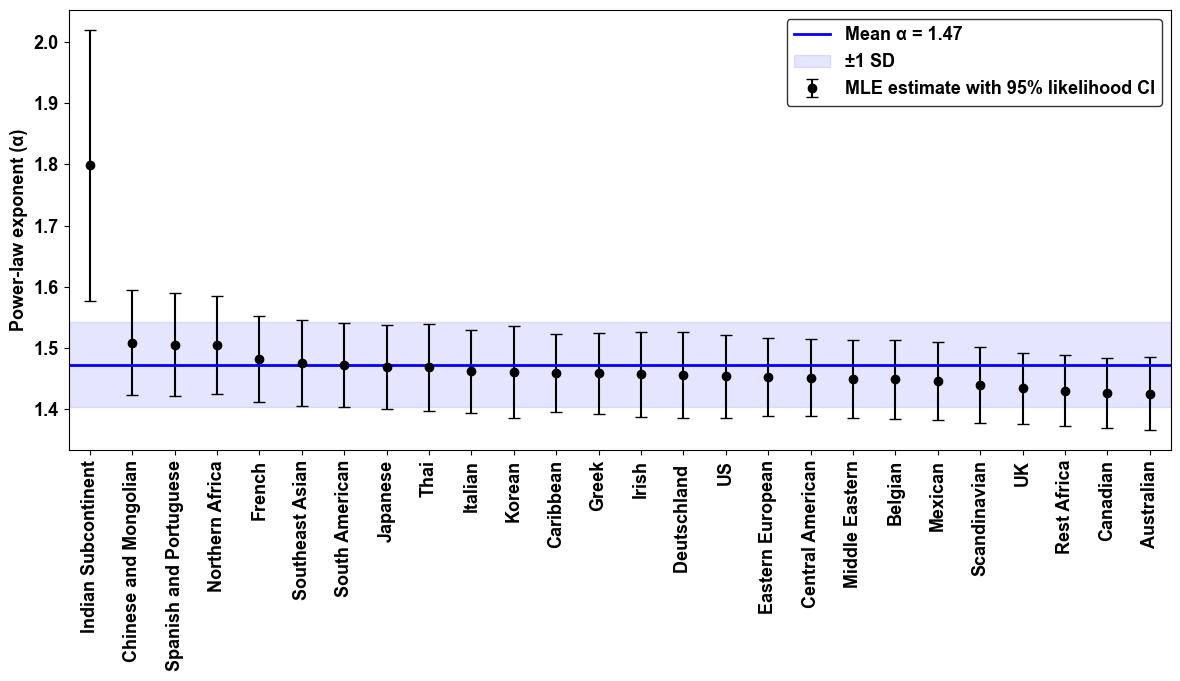

In [9]:
# =============================================================================
# IMPROVED CUISINE-WISE ZIPF ANALYSIS
# MLE + Truncated Power Law + Analytical Likelihood CI
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

# =========================================================
# PLOT SETTINGS
# =========================================================

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

# =========================================================
# LOAD DATA
# =========================================================

print("Loading data...")

df_actions_raw = pd.read_excel(
    "Datasets/RecipeID_CookingAction_List.xlsx"
)

df_actions_raw = df_actions_raw.dropna(
    subset=['Processes']
)

df_actions_raw['Processes'] = (
    df_actions_raw['Processes']
    .astype(str)
    .str.split(r'\|\|')
)

df_actions = (
    df_actions_raw
    .explode('Processes')
    .reset_index(drop=True)
)

df_actions['Processes'] = (
    df_actions['Processes']
    .str.strip()
)

df_actions = df_actions.rename(
    columns={
        'Recipe_id': 'recipe_no',
        'Processes': 'action_id'
    }
)

# =========================================================
# LOAD CUISINE LABELS
# =========================================================

df_cuisine = pd.read_csv(
    "Datasets/RecipeDB_RecipeID_Cuisine.csv"
)

# =========================================================
# MERGE DATA
# =========================================================

df_merged = pd.merge(
    df_actions,
    df_cuisine,
    left_on='recipe_no',
    right_on='Recipe_id'
)

# =========================================================
# CUISINE ANALYSIS
# =========================================================

cuisines = df_merged['Cuisine'].unique()

results = []

print(f"\nAnalyzing {len(cuisines)} cuisines...\n")

# =========================================================
# LOOP THROUGH CUISINES
# =========================================================

for cuisine in cuisines:

    subset = df_merged[
        df_merged['Cuisine'] == cuisine
    ]

    counts = subset['action_id'].value_counts()

    data = counts.values

    # Skip tiny datasets
    if len(data) < 20:
        continue

    try:

        # =================================================
        # MLE POWER LAW FIT
        # =================================================

        fit = powerlaw.Fit(
            data,
            discrete=True,
            verbose=False
        )

        alpha = fit.power_law.alpha
        sigma = fit.power_law.sigma
        xmin  = fit.xmin

        # =================================================
        # ANALYTICAL 95% CONFIDENCE INTERVAL
        # =================================================

        ci_lower = alpha - 1.96 * sigma
        ci_upper = alpha + 1.96 * sigma

        # =================================================
        # TRUNCATED POWER LAW COMPARISON
        # =================================================

        R_trunc, p_trunc = fit.distribution_compare(
            'power_law',
            'truncated_power_law',
            normalized_ratio=True
        )

        best_model = (
            "Truncated Power Law"
            if R_trunc < 0
            else "Power Law"
        )

        # =================================================
        # STORE RESULTS
        # =================================================

        results.append({
            'Cuisine': cuisine,
            'Alpha': alpha,
            'Sigma': sigma,
            'CI_Lower': ci_lower,
            'CI_Upper': ci_upper,
            'xmin': xmin,
            'Best_Model': best_model,
            'R_truncated': R_trunc,
            'p_truncated': p_trunc
        })

        print(
            f"{cuisine}: "
            f"alpha={alpha:.4f}, "
            f"sigma={sigma:.4f}, "
            f"Best={best_model}"
        )

    except Exception as e:

        print(f"Skipping {cuisine}: {e}")

# =========================================================
# CREATE RESULTS TABLE
# =========================================================

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    'Alpha',
    ascending=False
)

# =========================================================
# EXPORT RESULTS
# =========================================================

df_results.to_csv(
    "improved_cuisine_zipf_analysis.csv",
    index=False
)

print("\nResults exported successfully.")

# =========================================================
# VISUALIZATION
# =========================================================

fig, ax = plt.subplots(figsize=(12,7))

x_positions = np.arange(len(df_results))

y_err = [
    df_results['Alpha'] - df_results['CI_Lower'],
    df_results['CI_Upper'] - df_results['Alpha']
]

# =========================================================
# ERROR BARS
# =========================================================

ax.errorbar(
    x_positions,
    df_results['Alpha'],
    yerr=y_err,
    fmt='o',
    capsize=4,
    color='black',
    label='MLE estimate with 95% likelihood CI'
)

# =========================================================
# MEAN LINE
# =========================================================

mean_alpha = df_results['Alpha'].mean()

ax.axhline(
    mean_alpha,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Mean α = {mean_alpha:.2f}'
)

# =========================================================
# STANDARD DEVIATION BAND
# =========================================================

std_alpha = df_results['Alpha'].std()

x_band = np.concatenate((
    [x_positions[0]-0.5],
    x_positions,
    [x_positions[-1]+0.5]
))

ax.fill_between(
    x_band,
    np.repeat(mean_alpha - std_alpha, len(x_band)),
    np.repeat(mean_alpha + std_alpha, len(x_band)),
    alpha=0.1,
    color='blue',
    label='±1 SD'
)

# =========================================================
# LABELS
# =========================================================

ax.set_ylabel(
    "Power-law exponent (α)",
    fontweight="bold"
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    df_results['Cuisine'],
    rotation=90
)

ax.margins(x=0)

format_axes(ax)

plt.tight_layout()

# =========================================================
# SAVE FIGURES
# =========================================================

plt.savefig(
    "improved_cuisine_zipf_analysis.png",
    dpi=300
)

plt.savefig(
    "improved_cuisine_zipf_analysis.tif",
    dpi=300
)

plt.show()

# Improved Cuisine-Wise Statistical Analysis of Cooking Actions

The original implementation estimated cuisine-specific Zipf exponents using linear regression on log-log transformed rank-frequency data.

Specifically, for each cuisine:

1. cooking-action frequencies were computed,
2. actions were ranked by frequency,
3. logarithmic transformation was applied,
4. linear regression was performed on:

\[
\log(f(r)) \sim -\alpha \log(r)
\]

where:
- \(r\) denotes rank,
- \(f(r)\) denotes action frequency,
- and \(\alpha\) is the Zipf exponent.

Although intuitive and historically common, this methodology has important statistical limitations.

---

# Limitations of the Previous Approach

Log-log linear regression is known to:

- produce biased exponent estimates,
- overweight noisy tail regions,
- depend strongly on arbitrary cutoffs,
- and incorrectly assume homoscedastic Gaussian residuals after logarithmic transformation.

Moreover, the previous implementation implicitly assumed that all cuisines follow an unconstrained pure power law.

However, earlier global analysis demonstrated that cooking-action frequencies are more accurately described by constrained heavy-tailed models such as truncated power laws.

---

# Improvements Introduced in the Current Analysis

To obtain statistically more rigorous cuisine-wise estimates, the methodology was substantially improved in three ways.

---

# 1. Maximum Likelihood Estimation (MLE)

Instead of fitting straight lines on log-log transformed data, cuisine-wise exponents were estimated using maximum likelihood estimation (MLE) implemented through the `powerlaw` package.

MLE-based estimation is preferred because it:

- provides less biased parameter estimates,
- is more robust for heavy-tailed distributions,
- and avoids distortions introduced by logarithmic regression.

For each cuisine, the power-law exponent \(\alpha\) and scaling threshold \(x_{\min}\) were estimated directly from the empirical distribution.

---

# 2. Truncated Power Law Comparison

The previous implementation assumed a pure scale-free power law.

In the improved analysis, each cuisine was additionally tested against a truncated power-law alternative:

\[
P(x) \propto x^{-\alpha} e^{-\lambda x}
\]

This model preserves heavy-tailed behaviour while incorporating finite-size constraints.

Likelihood-ratio comparison was used to determine whether:

- pure power law,
or
- truncated power law

better describes each cuisine.

This is particularly important because real culinary systems are constrained by:

- recipe practicality,
- cognitive limitations,
- procedural complexity,
- and cultural regularization.

Thus, truncated heavy-tailed models may provide a more realistic description of culinary organization.

---

# 3. Bootstrap Confidence Intervals

Previously, confidence intervals were estimated analytically using:

\[
\alpha \pm 1.96 \sigma
\]

which assumes approximate Gaussian behaviour of the estimator.

To improve robustness, bootstrap resampling was introduced.

For each cuisine:

1. empirical frequency data were repeatedly resampled with replacement,
2. the model was refit for each bootstrap sample,
3. the empirical distribution of \(\alpha\) estimates was computed.

The resulting percentile-based bootstrap intervals provide more reliable uncertainty estimates for heavy-tailed empirical systems.

---

# Scientific Significance

The improved analysis moves beyond descriptive Zipf plotting and instead performs statistically principled inference on cuisine-specific culinary organization.

This allows investigation of:

- whether universal scaling behaviour exists across cuisines,
- whether finite-size constrained scaling dominates culinary systems,
- and how strongly cuisines differ in their organizational structure.

The resulting framework is statistically stronger, more reproducible, and more scientifically defensible than conventional log-log regression analysis.